# ***Ⅲ. 이미지 데이터 처리***
## ***03. 이미지 데이터의 분류***
- 우리는 인공지능을 통해 AND, OR 연산을 분류할 수 있음을 1일차에 확인한 바 있습니다
- 이미지도 숫자이기 때문에 분류를 할 수 있습니다

In [ ]:
# imshow함수 준비
import cv2
import numpy as np
from matplotlib import pyplot as plt

def cv2_imshow(img, title='Image', figsize=(5,5), axis='on'):
    # BGR -> RGB 변환
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis(axis)
    plt.show()

## ***해밍거리***
- 두 데이터간에 서로 다른 성분들이 몇개 있는지 측정합니다
- 따라서 해밍거리가 작을수록 유사한 이미지가 됩니다

In [ ]:
import numpy as np

img1 = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 1, 0]
])

img2 = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [1, 0, 0]
])

diff = img1 != img2

print(diff)

[[False  True False]
 [False  True False]
 [False  True False]]


In [ ]:
hamming_distance = np.sum(diff)

print(hamming_distance)

3


## ***해밍거리를 이용한 이미지 유사도 측정***
- 이제는 실제 숫자를 나타내는 이미지 데이터들간의 해밍거리를 측정합니다
- 가로, 세로 해상도 5x8 공간으로 비교적 작은 해상도에서 표시된 숫자임을 먼저 인지해주시기 바랍니다

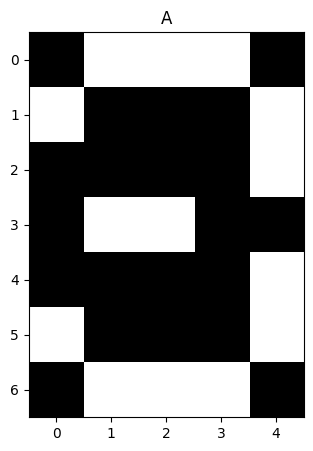

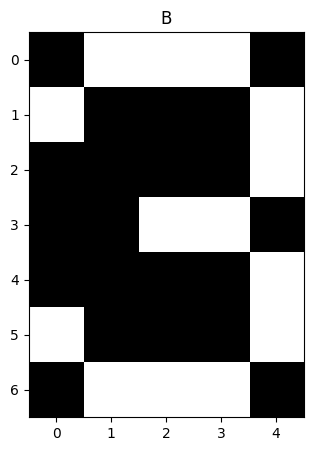

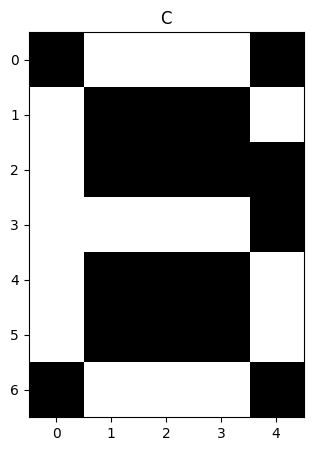

In [ ]:
import numpy as np

A = np.array([
    [0, 1, 1, 1, 0],
    [1, 0, 0, 0, 1],
    [0, 0, 0, 0, 1],
    [0, 1, 1, 0, 0],
    [0, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [0, 1, 1, 1, 0]
]).astype(np.uint8) * 255
cv2_imshow(A, title='A')

B = np.array([
    [0, 1, 1, 1, 0],
    [1, 0, 0, 0, 1],
    [0, 0, 0, 0, 1],
    [0, 0, 1, 1, 0],
    [0, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [0, 1, 1, 1, 0]
]).astype(np.uint8) * 255
cv2_imshow(B, title='B')

C = np.array([
    [0, 1, 1, 1, 0],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 0],
    [1, 1, 1, 1, 0],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [0, 1, 1, 1, 0]
]).astype(np.uint8) * 255
cv2_imshow(C, title='C')

### ***각 이미지간 해밍거리 계산***

In [ ]:
happing_distanceAB = np.sum(A != B)
happing_distanceBC = np.sum(B != C)
happing_distanceCA = np.sum(C != A)

print(A!=B)
print(happing_distanceAB)
print()

print(B!=C)
print(happing_distanceBC)
print()

print(C!=A)
print(happing_distanceCA)
print()

[[False False False False False]
 [False False False False False]
 [False False False False False]
 [False  True False  True False]
 [False False False False False]
 [False False False False False]
 [False False False False False]]
2

[[False False False False False]
 [False False False False False]
 [ True False False False  True]
 [ True  True False False False]
 [ True False False False False]
 [False False False False False]
 [False False False False False]]
5

[[False False False False False]
 [False False False False False]
 [ True False False False  True]
 [ True False False  True False]
 [ True False False False False]
 [False False False False False]
 [False False False False False]]
5



## ***MNIST***
- 손글씨 데이터셋입니다
- 해상도는 28x28 입니다
- 데이터 자체는 이미지 입니다
- 학습용 이미지 60,000정
- 테스트용 이미지 10,000장
- 몇몇 딥러닝 라이브러리에서 이 이미지를 다운로드 받는 기능을 제공합니다
- 우리는 tensorflow를 이용해 MNIST데이터를 다운로드 받아보겠습니다

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
학습용 입력이미지: 60000장, 테스트용 입력이미지: 10000장
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 003 018 018 018 126 136 175 026 166 255 247 127 000 000 000 000 
000 000 000 000 000 000 000 000 030 036 094 154 170 253 253 253 253 253 225 172 253 242 195 064 000 000 000 000 
000 000 000 000 000 000 000 049 238 253 253 253 253 253 253 253 253 251 093 082 082 056 039 000 000 000 000 000 
000 000

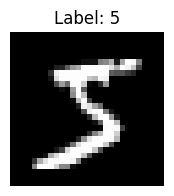

In [ ]:
import matplotlib.pyplot as plt
import math
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

starting = 0
samples = 1

sqrt_samples = int(math.sqrt(samples))

print(f'학습용 입력이미지: {len(x_train)}장, 테스트용 입력이미지: {len(x_test)}장')

# 샘플 16개 시각화
plt.figure(figsize=(sqrt_samples*2, sqrt_samples*2))
for i in range(starting, samples + starting):
    for row in x_train[i]:
        for col in row:
            print(f'{int(col):03d}', end=' ')
        print()
    print("====================================================================")
    plt.subplot(sqrt_samples, sqrt_samples, (i-starting)%samples + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

### ***특정 숫자 이미지 확인***
- 모든 숫자 이미지가 같은 픽셀에 비슷한 값을 갖는것은 아님을 확인합니다

학습용 입력이미지: 60000장
테스트용 입력이미지: 10000장
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 115 121 162 253 253 213 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 063 107 170

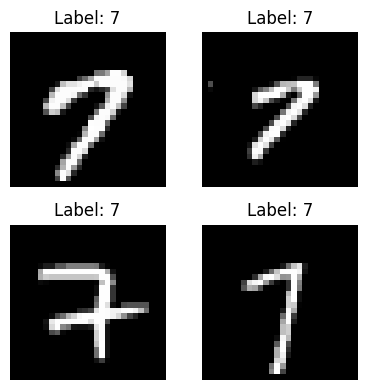

In [ ]:
import matplotlib.pyplot as plt
import math
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 보고 싶은 숫자 이미지
target_class = 7

# 몇 장 볼 건지
samples = 4

sqrt_samples = int(math.sqrt(samples))

print(f'학습용 입력이미지: {len(x_train)}장')
print(f'테스트용 입력이미지: {len(x_test)}장')

target_indices = []

for i in range(len(y_train)):
    if y_train[i] == target_class:
        target_indices.append(i)

# ==============================
# 시각화
# ==============================
plt.figure(figsize=(sqrt_samples * 2, sqrt_samples * 2))

for idx in range(samples):

    real_idx = target_indices[idx]

    # 픽셀값 출력
    for row in x_train[real_idx]:
        for col in row:
            print(f'{int(col):03d}', end=' ')
        print()

    print("======================================================")

    # 이미지 출력
    plt.subplot(sqrt_samples, sqrt_samples, idx + 1)
    plt.imshow(x_train[real_idx], cmap='gray')
    plt.title(f"Label: {y_train[real_idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## ***MNIST 데이터 단순화하기***
- MNIST 데이터는 28x28로 비교적 픽셀 수가 많습니다
- 이를 5x8로 줄인 후 같은 숫자 이미지끼리 픽셀 수준으로 확인해봅니다



학습용 입력이미지: 60000장
테스트용 입력이미지: 10000장
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 1 1 0]
 [0 1 1 1 0]
 [0 1 1 1 0]
 [0 1 1 1 0]
 [0 1 1 0 0]
 [0 1 1 0 0]]
[[0 0 0 0 0]
 [0 0 0 0 0]
 [1 1 1 1 0]
 [0 1 1 1 0]
 [0 0 1 1 0]
 [0 1 1 0 0]
 [0 1 1 0 0]
 [0 0 0 0 0]]
[[0 0 0 0 0]
 [0 0 0 0 0]
 [1 1 1 1 0]
 [0 0 1 1 0]
 [0 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 1 0]
 [0 0 1 0 0]]
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 1 1 0]
 [0 1 1 1 0]
 [0 0 1 1 0]
 [0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 1 0 0]]
[[0 0 0 0 0]
 [0 0 0 0 0]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [0 0 1 1 0]
 [0 0 1 1 0]
 [0 0 1 1 0]
 [0 0 1 1 0]]
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 1 1 0]
 [0 1 1 1 0]
 [0 0 1 1 0]
 [0 1 1 0 0]
 [0 1 1 0 0]
 [0 1 0 0 0]]
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 1 1 0]
 [0 1 1 1 0]
 [0 1 1 1 0]
 [0 1 1 0 0]
 [0 1 1 0 0]
 [0 1 0 0 0]]
[[0 0 0 0 0]
 [0 0 0 0 0]
 [1 1 1 1 0]
 [0 0 0 1 0]
 [0 0 1 1 0]
 [0 0 1 1 0]
 [0 0 1 1 0]
 [0 0 1 1 0]]
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 0]
 [0 0 1 1 0]
 [0 1 1 0 0]
 [1 1 1 0 0]]
[[0 0 0 0 0]
 [0 0

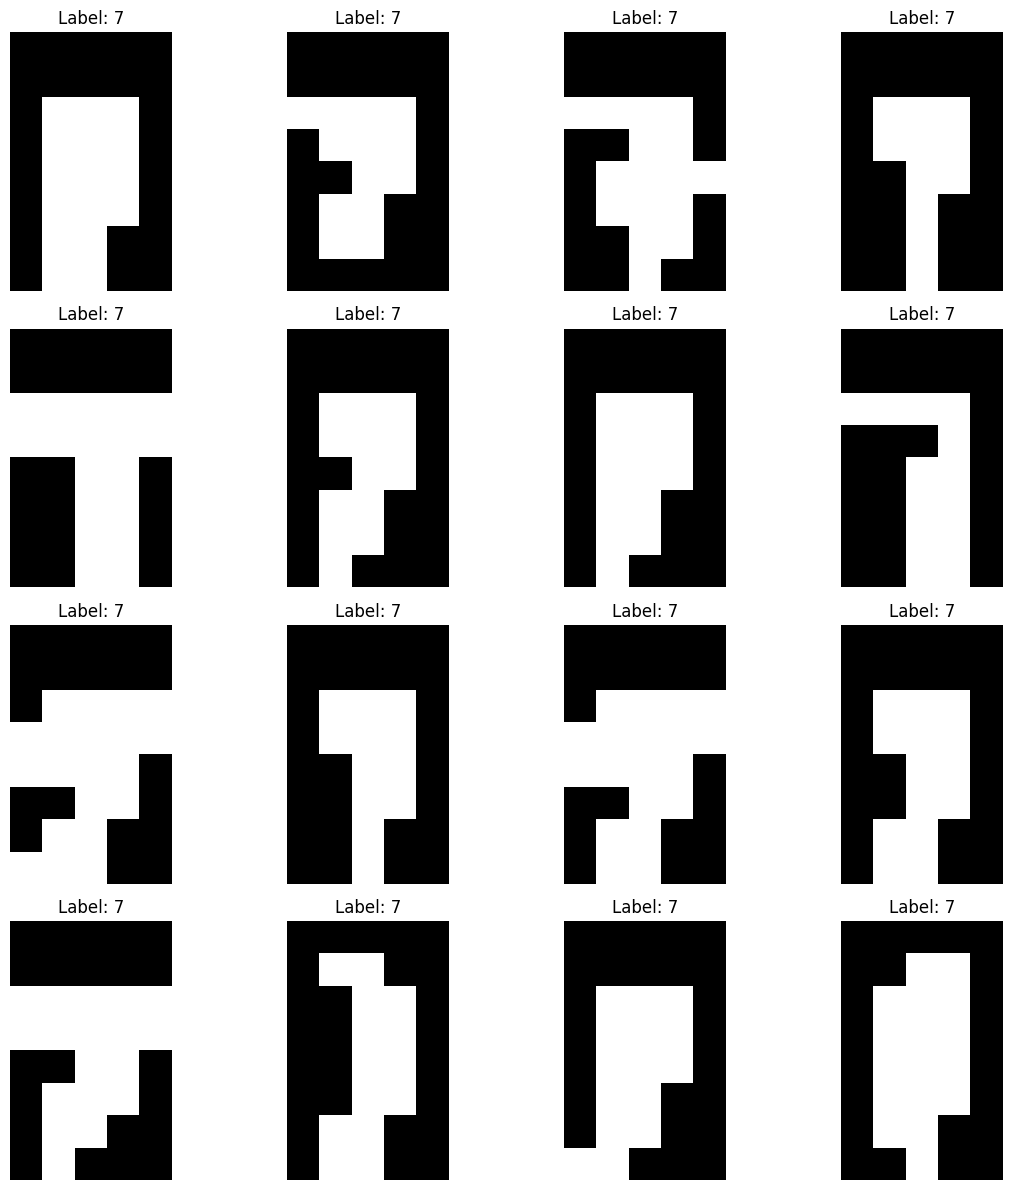

In [ ]:
import matplotlib.pyplot as plt
import math
import cv2
import numpy as np
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 보고 싶은 숫자 이미지 수를 적어주세요
# 한번에 너무 많은 수보다는 적은 수로 시작해서 천천히 늘려주세요
target_class = 7

# 총 몇 장을 볼 것인지를 제곱수로 정해주세요
# 예를 들면 4x4 = 16
samples = 16

sqrt_samples = int(math.sqrt(samples))

print(f'학습용 입력이미지: {len(x_train)}장')
print(f'테스트용 입력이미지: {len(x_test)}장')

target_indices = []

for i in range(len(y_train)):
    if y_train[i] == target_class:
        target_indices.append(i)

plt.figure(figsize=(sqrt_samples * 3, sqrt_samples * 3))

for idx in range(samples):

    real_idx = target_indices[idx]

    # 원본 이미지
    img = x_train[real_idx]

    # 5x8로 리사이즈
    resized = cv2.resize(img, (5, 8), interpolation=cv2.INTER_AREA)

    # 검정색(0) 이면 0, 0이아닌 모든 픽셀 값은 1로 치환합니다
    binary = np.where(resized == 0, 0, 1)

    # 출력
    print(binary)

    print("======================================================")

    # 시각화
    plt.subplot(sqrt_samples, sqrt_samples, idx + 1)
    plt.imshow(binary, cmap='gray')
    plt.title(f"Label: {y_train[real_idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## ***데이터 속성 기반의 분류***

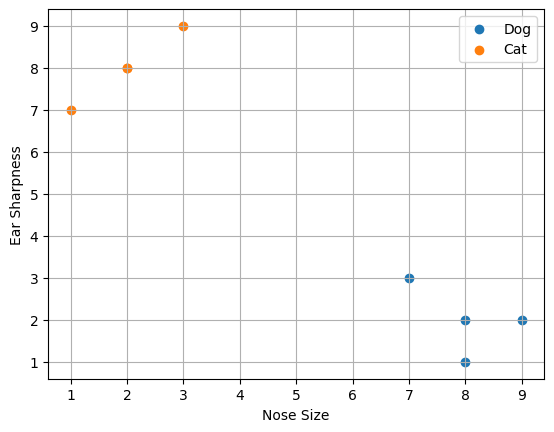

In [ ]:
import matplotlib.pyplot as plt

# 특징 데이터
# x = 코 크기
# y = 귀 뾰족함 정도

dog_x = [8, 7, 9, 8]
dog_y = [2, 3, 2, 1]

cat_x = [2, 3, 1, 2]
cat_y = [8, 9, 7, 8]

# 시각화
plt.scatter(dog_x, dog_y, label='Dog')
plt.scatter(cat_x, cat_y, label='Cat')

plt.xlabel('Nose Size')
plt.ylabel('Ear Sharpness')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import numpy as np

# 학습 데이터
# x = 입의 길이
# y = 귀의 뾰족함 정도

dogs = np.array([
    [8, 2],
    [7, 3],
    [9, 2],
    [8, 1]
])

cats = np.array([
    [2, 8],
    [3, 9],
    [1, 7],
    [2, 8]
])

# 데이터 합치기
X_train = np.vstack((dogs, cats))

# 라벨
# 개 = 0
# 고양이 = 1
y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1])

# 분류할 새로운 데이터
test = np.array([3, 7])

# 거리 계산 (유클리드 거리)
distances = np.sqrt(np.sum((X_train - test) ** 2, axis=1))

print("거리:")
print(distances)


# 가장 가까운 K개 찾기
k = 3

nearest_indices = np.argsort(distances)[:k]

print("\n가까운 데이터 인덱스:")
print(nearest_indices)

print("\n가까운 데이터 라벨:")
print(y_train[nearest_indices])

# 다수결
nearest_labels = y_train[nearest_indices]

prediction = np.bincount(nearest_labels).argmax()

# 결과 출력
if prediction == 0:
    print("\n예측 결과: 개")
else:
    print("\n예측 결과: 고양이")

거리:
[7.07106781 5.65685425 7.81024968 7.81024968 1.41421356 2.
 2.         1.41421356]

가까운 데이터 인덱스:
[7 4 6]

가까운 데이터 라벨:
[1 1 1]

예측 결과: 고양이


## ***Support Vector Machine 방식으로 선긋기***

-1x + 1y + 0 = 0
Margin: 2.828
-1x + 1y + 2 = 0
Margin: 1.414
-1x + 1y + -2 = 0
Margin: 2.828


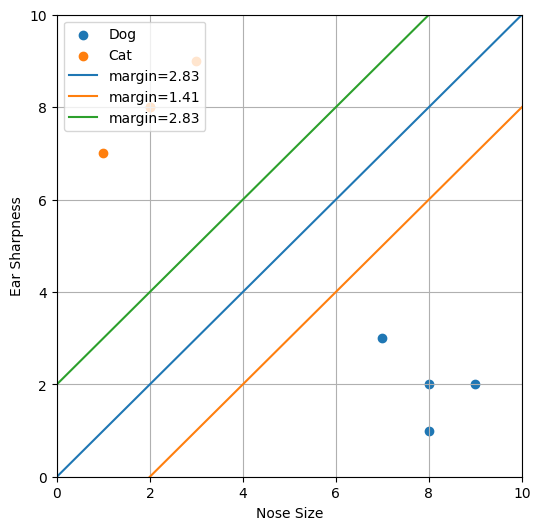

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터

# 개
dogs = np.array([
    [8, 2],
    [7, 3],
    [9, 2],
    [8, 1]
])

# 고양이
cats = np.array([
    [2, 8],
    [3, 9],
    [1, 7],
    [2, 8]
])

# 직선 후보
# ax + by + c = 0
#
# y = -x + 10
# → x + y - 10 = 0
lines = [
    (-1, 1, 0),   # y = x
    (-1, 1, 2),   # y = x - 2
    (-1, 1, -2)   # y = x + 2
]

# 점-직선 거리 계산
def point_line_distance(a, b, c, x0, y0):

    return abs(a*x0 + b*y0 + c) / np.sqrt(a**2 + b**2)

# margin 계산
# (가장 가까운 점까지 거리)
def calculate_margin(a, b, c):

    distances = []

    # 개 점들
    for point in dogs:

        d = point_line_distance(
            a, b, c,
            point[0], point[1]
        )

        distances.append(d)

    # 고양이 점들
    for point in cats:

        d = point_line_distance(
            a, b, c,
            point[0], point[1]
        )

        distances.append(d)

    # 가장 가까운 점 거리
    return min(distances)

# 시각화
plt.figure(figsize=(6,6))

plt.scatter(dogs[:,0], dogs[:,1], label='Dog')
plt.scatter(cats[:,0], cats[:,1], label='Cat')

x = np.linspace(0, 10, 100)


# 선 출력
for a, b, c in lines:

    # ax + by + c = 0
    # y = (-ax - c)/b

    y = (-a*x - c) / b

    margin = calculate_margin(a, b, c)

    print(f'{a}x + {b}y + {c} = 0')
    print(f'Margin: {margin:.3f}')
    print('========================')

    plt.plot(x, y, label=f'margin={margin:.2f}')

# 그래프 설정
plt.xlim(0,10)
plt.ylim(0,10)

plt.xlabel('Nose Size')
plt.ylabel('Ear Sharpness')

plt.legend()
plt.grid(True)

plt.show()

## ***딥러닝 방식의 이미지 분류***

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# 데이터셋 다운로드
# 28x28 크기의 손글씨 이미지들
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 정규화 및 차원 확장 (28,28) → (28,28,1)
# 색상 성분을 0 ~ 1 사이의 소수점 값으로 변환
x_train = x_train.reshape(-1,28,28,1).astype('float32') / 255.0
x_test  = x_test.reshape(-1,28,28,1).astype('float32') / 255.0

# 학습을 위한 인공신경망 모델 정의
# 28x28 이미지를 입력으로 하여 10개의 숫자를 출력하는 모델
# 10개의 숫자: 숫자 0일 확률, 숫자 1일 확률, 숫자 2일 확률 ... 숫자 9일 확률
model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# --- 3. 컴파일 ---
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# --- 4. 학습 ---
model.fit(x_train, y_train, epochs=1, batch_size=64, validation_split=0.1)

# --- 5. 테스트 정확도 ---
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

### ***우리의 손글씨를 인식 시켜보기***
- 학습할 때 이미지를 28x28크기의 흑백이미지로 구성하였습니다
- 학습할 때 이미지 색상 성분을 정규화 하였습니다
- 그 과정을 동일하게 하여 인식을 시키면 10개의 숫자가 나올 것입니다
- 그 중에서 가장 큰 숫자가 인식 결과가 됩니다
### ***확인해볼 사항***
- 글씨를 작게 쓴 그림을 인식시켜보기
- 글씨를 꽉 차게 쓴 그림을 인식시켜보기
- 검정 바탕에 흰색 글씨 그림을 인식시켜보기
- 흰색 바탕에 검정색 글씨 그림을 인식시켜보기

In [ ]:
import cv2
import numpy as np

# 이미지를 흑백으로 읽기
img = cv2.imread("3.png", cv2.IMREAD_GRAYSCALE)

# 2. 전처리 (28x28, 정규화)
img = cv2.resize(img, (28, 28))        # 크기 맞추기
img = img.astype("float32") / 255.0    # 0~1 정규화

# 3. 모델 입력 형태 맞추기 (batch, 28, 28, 1)
img = img.reshape(1, 28, 28, 1)

# 4. 예측
pred = model.predict(img)
import numpy as np

np.set_printoptions(suppress=True, precision=6)
print("각 숫자별 확률:")
for i, p in enumerate(pred[0]):
    print(f"{i}: {p:.6f}")

# 5. argmax로 최종 숫자
digit = np.argmax(pred[0])
print("예측된 숫자:", digit)